# Notebook n°2: Paired-Feature Visualization (Milestone 1 output)

**Pipeline stage:** visual inspection of the time-aligned `[audio | OEP]` matrices produced by
Milestone&nbsp;1 (M1).

**Scripts this notebook replaces / demonstrates**
| Script | What it does |
|--------|--------------|
| `scripts/plot_paired_features.py` | interactive single-file PDF plots |
| `scripts/batch_plot_paired.py` | batch PDF generation for a whole cohort |
| `pneumophonic_analysis/visualization.py` (`Visualizer`) | the reusable plotting class |

Each paired HDF5 file holds one subject × task recording: per-frame audio features
(`f0`, `energy`, `spectral_centroid`, `mfcc_0..12`), per-frame OEP respiratory features
(`vcw`, `vrc`, `vab`, `flow_*`, `pct_rc`, `pct_ab`, `delta_*`), **and** the full
STFT / mel / MFCC matrices used to build them.

> **Plot types demonstrated here:** dual-axis line (energy vs volume, F0 vs flow),
> compartmental line plot, correlation heatmap, STFT spectrogram, mel-spectrogram,
> MFCC heatmap, F0 trace (with mean±SD band), and chest-wall volume with FRC zones.

## 0. Setup
Locate the repository, import the package, and find the paired HDF5 corpus.

In [1]:

import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display

# Make the repo importable no matter where Jupyter was launched from
REPO = Path.cwd()
while not (REPO / "pneumophonic_analysis").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "scripts"))

from pneumophonic_analysis.paired_features import PairedFeatureExtractor
from pneumophonic_analysis.visualization import Visualizer

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110

PAIRED_DIR = REPO / "data_target" / "healthy_subjects" / "paired"
assert PAIRED_DIR.exists(), f"No paired/ dir at {PAIRED_DIR}: run scripts/batch_extract.py first."
h5_files = sorted(PAIRED_DIR.glob("*.h5"))
print(f"Found {len(h5_files)} paired HDF5 files in {PAIRED_DIR.relative_to(REPO)}")


# --- Presentation-safe subject aliases (figures may be reused in talks) -----
# Real IDs stay in code; titles show a stable generic alias ("S01".."S39"),
# assigned by alphabetical order of the corpus and identical across notebooks.
_ALL_SIDS = sorted({f.stem.split('_', 1)[0] for f in h5_files})
ALIAS = {s: f"S{i+1:02d}" for i, s in enumerate(_ALL_SIDS)}
def anon(sid): return ALIAS.get(sid, sid)

Found 550 paired HDF5 files in data_target\healthy_subjects\paired


## 1. Load one example recording
We use a sustained-phonation task (`a_2`, maximum phonation time on /a/) because the **FRC crossing** is well defined for single-breath phonation.

In [2]:

def pick(task_suffix):
    # Return the first available HDF5 file whose task matches.
    for f in h5_files:
        if f.stem.endswith(task_suffix):
            return f
    return h5_files[0]

H5 = pick("_a_2")
df, meta = PairedFeatureExtractor.load_hdf5(H5)
SID, TASK = meta["subject_id"], meta["task_name"]

print(f"Example file : {H5.name}")
print(f"Subject/Task : {SID} / {TASK}")
print(f"Aligned matrix: {df.shape[0]} frames x {df.shape[1]} features")
print(f"Duration     : {df['time'].iloc[-1]:.2f} s")

# Two-compartment sanity check: Vrc + Vab should equal Vcw
err = (df['vrc'] + df['vab'] - df['vcw']).abs().mean()
print(f"Compartmental check |Vrc + Vab - Vcw| = {err:.2e} L  ->  {'OK' if err < 1e-2 else 'CHECK MAPPING'}")
df.head(3)

Example file : AlMo_a_2.h5
Subject/Task : AlMo / a_2
Aligned matrix: 1086 frames x 35 features
Duration     : 16.27 s
Compartmental check |Vrc + Vab - Vcw| = 3.25e-07 L  ->  OK


,delta_vab,delta_vcw,delta_vcw_frc,delta_vrc,energy,f0,f0_raw,flow_ab,flow_cw,flow_rc,...,rms_audio,spectral_centroid,time,vab,vcw,voiced,voicing_prob,vrc,vrca,vrcp
0,0.000000,0.000000,1.076425,0.000000,0.000019,NaN,NaN,-0.696041,-1.011829,-0.315775,...,0.002321,220.002859,0.000,6.779289,23.090599,0.0,0.010000,16.311310,4.249119,12.062191
1,-0.008834,-0.013629,1.062796,-0.004795,0.000140,NaN,NaN,-0.658133,-0.975035,-0.316893,...,0.015496,167.977297,0.015,6.770455,23.076970,0.0,0.010000,16.306515,4.246654,12.059862
2,-0.020998,-0.031170,1.045255,-0.010172,0.017480,120.999409,120.999409,-0.559772,-0.870549,-0.310776,...,0.033661,39.827573,0.030,6.758291,23.059429,1.0,0.014689,16.301138,4.243646,12.057492


## 2. Audio loudness vs chest-wall volume
Task `a_2` (maximum phonation time on /a/), one example subject.\
Acoustic loudness (left axis) against the volume excursion `ΔVcw` (right axis).

The loudness curve is `rms_audio`: the RMS of the *raw* audio.\
The pipeline's `energy` feature is computed on the pre-emphasised, L2-normalised, denoised signal. That chain annihilates the steady low-frequency vowel and collapses a long phonation to a single onset spike (drawn faint and dotted for contrast). `rms_audio` shows the truth: loudness stays broadly sustained while the chest wall deflates.

**Observations:**\
Loudness is roughly flat: a small onset peak, then a plateau.\
`ΔVcw` shows a large, steady decrease over the same window.\
In steady phonation the audio links to volume depletion, not to a matching loudness change.\
The single-peak `energy` curve is a computation artifact, not weak phonation.

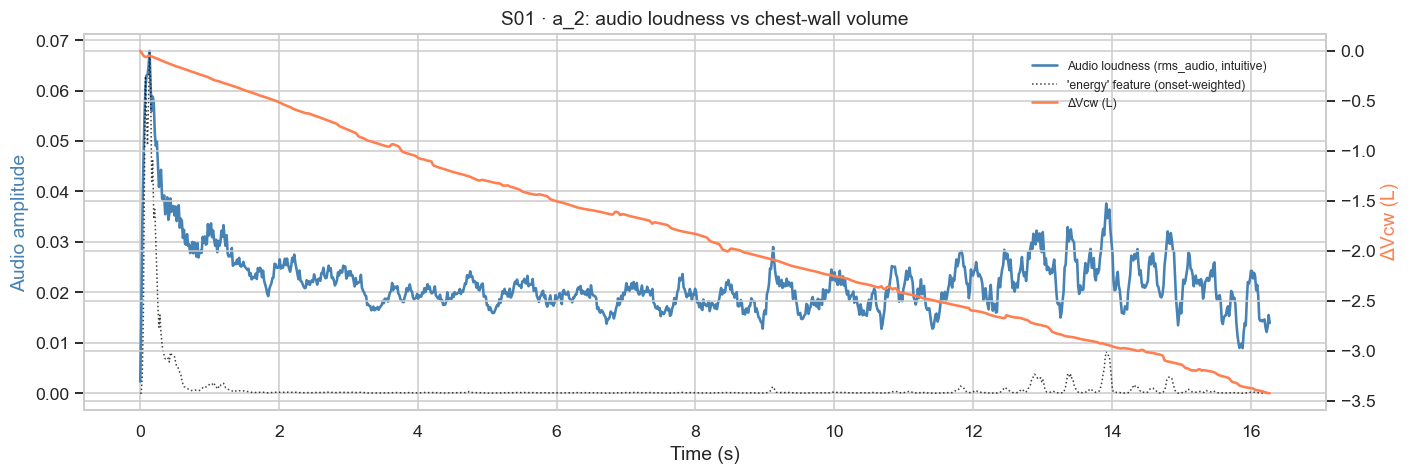

In [3]:
fig, ax1 = plt.subplots(figsize=(13, 4.5))
# rms_audio = true raw loudness (sustained); 'energy' is pre-emphasised+normalised
# and collapses to an onset spike, shown faint/scaled for contrast only.
amp = df['rms_audio'] if 'rms_audio' in df.columns else df['energy']
ax1.plot(df['time'], amp, color='steelblue', lw=1.7, label='Audio loudness (rms_audio, intuitive)')
if 'rms_audio' in df.columns and df['energy'].max() > 0:
    en = df['energy'] / df['energy'].max() * float(amp.max())
    ax1.plot(df['time'], en, color='black', lw=1.0, ls=':', alpha=0.75,
             label="'energy' feature (onset-weighted)")
ax1.set_ylabel('Audio amplitude', color='steelblue'); ax1.set_xlabel('Time (s)')
ax2 = ax1.twinx()
ax2.plot(df['time'], df['delta_vcw'], color='coral', lw=1.7, label='ΔVcw (L)')
ax2.set_ylabel('ΔVcw (L)', color='coral')
ax1.set_title(f"{anon(SID)} · {TASK}: audio loudness vs chest-wall volume")
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88), fontsize=8)
plt.tight_layout(); plt.show()

## 3. F0 vs expiratory flow (voiced frames only)
Task `a_2` (maximum phonation time on /a/), one example subject.\
Fundamental frequency against chest-wall flow `flow_cw`. Restricting to voiced frames removes the unvoiced gaps where F0 is undefined.

Voiced frames: 994 / 1086 (91.5%)


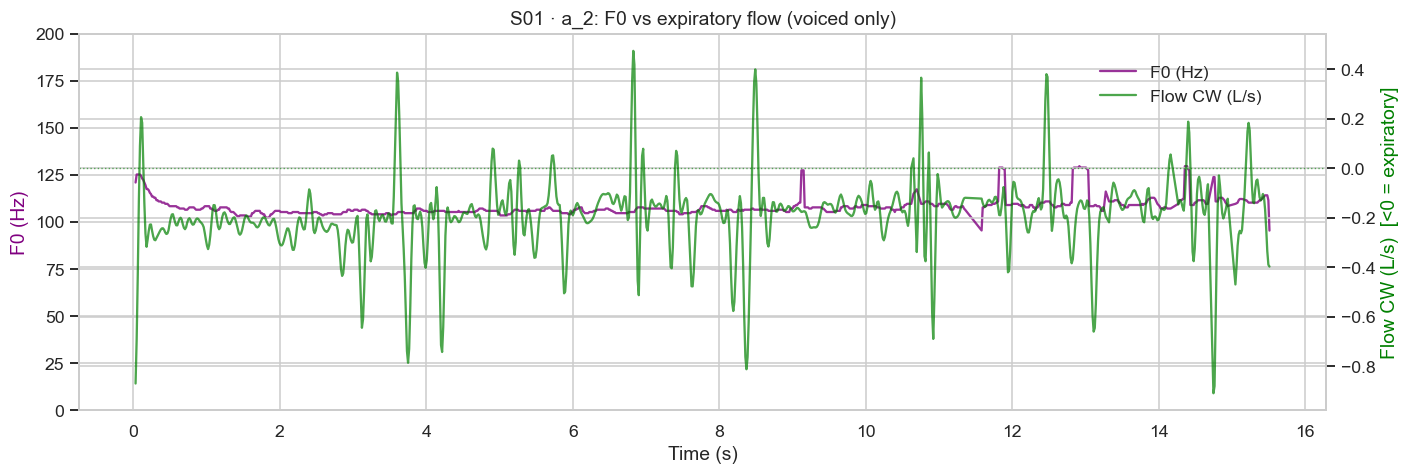

In [4]:
voiced = df[df['voiced'] == 1.0].copy()
print(f"Voiced frames: {len(voiced)} / {len(df)} ({len(voiced)/len(df)*100:.1f}%)")

fig, ax1 = plt.subplots(figsize=(13, 4.5))
ax1.plot(voiced['time'], voiced['f0'], color='purple', alpha=0.8, label='F0 (Hz)')
ax1.set_ylabel('F0 (Hz)', color='purple'); ax1.set_xlabel('Time (s)')
ax1.set_ylim(0, 200)
ax2 = ax1.twinx()
ax2.plot(voiced['time'], voiced['flow_cw'], color='green', alpha=0.7, label='Flow CW (L/s)')
ax2.axhline(0, color='green', ls=':', lw=0.9, alpha=0.6)   # zero-flow reference: expiration sits below it
ax2.set_ylabel('Flow CW (L/s)  [<0 = expiratory]', color='green')
ax1.set_title(f"{anon(SID)} · {TASK}: F0 vs expiratory flow (voiced only)")
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))
plt.tight_layout(); plt.show()

**Observations:**\
Task `a_2` (maximum phonation time on /a/), one example subject.\
F0 (purple) holds essentially flat: a steady held pitch.\
`flow_cw` (green) stays below the zero line for ~95 % of the vowel (≈ −0.19 L/s here): a small, roughly steady expiratory flow, not an oscillation about zero.\
The sign is negative by the pipeline's convention. `flow_cw = d(Vcw)/dt`, and the chest wall deflates monotonically (the same `ΔVcw` decrease seen in §2), so the time-derivative is negative throughout a held vowel.\
It reads small and only grazes zero because the deflation is slow (~3.4 L over ~16 s, so ~0.2 L/s mean), while a ±0.15 L/s ripple (heart-beat plus numerical differentiation) occasionally pokes a few samples above the axis.\
F0 and `flow_cw` do not track each other on this recording: pitch stays put while flow holds its steady expiratory level.

## 4. Compartmental strategy over time
Task `a_2` (maximum phonation time on /a/), one example subject.\
Instantaneous contribution of the rib cage (`%RC`) and abdomen (`%AB`) to total chest-wall volume, with `%RC + %AB = 1`. The split is the breathing strategy: rib-cage versus abdomen dominant phonation.

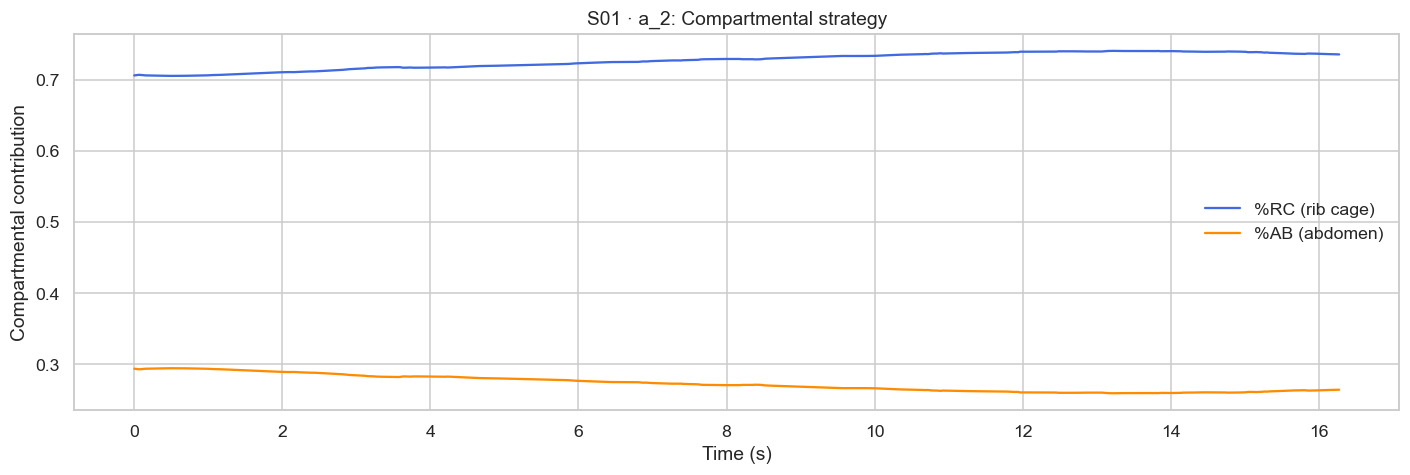

In [5]:

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(df['time'], df['pct_rc'], color='royalblue', label='%RC (rib cage)')
ax.plot(df['time'], df['pct_ab'], color='darkorange', label='%AB (abdomen)')
ax.set_ylabel('Compartmental contribution'); ax.set_xlabel('Time (s)')
ax.set_title(f"{anon(SID)} · {TASK}: Compartmental strategy")
ax.legend(); plt.tight_layout(); plt.show()

**Observations:**\
Task `a_2` (maximum phonation time on /a/), one example subject.\
`%RC` sits well above 0.5 (rib-cage-leaning) and drifts slightly as the lung empties.\
The split is fairly stable within this held vowel.\
The next cell compares the split across several subjects.

### 4b. Compartmental strategy varies across subjects
Task `a_2` (maximum phonation time on /a/), three example subjects.\
The split is a personal breathing strategy. Across the cohort the rib-cage share of a sustained /a/ ranges from ~56 % (abdomen-leaning) to ~78 % (strongly rib-cage). All subjects are rib-cage-majority, but the degree differs markedly.

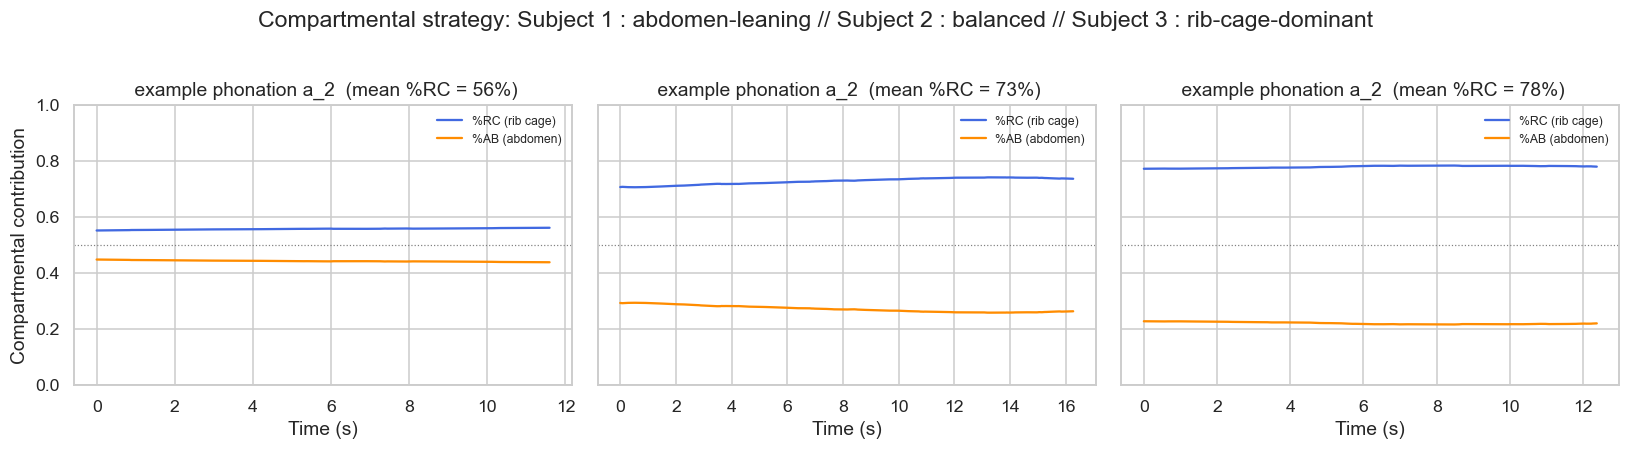

In [6]:
PAIRED = h5_files[0].parent
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, sid in zip(axes, ['SaMa', 'AlMo', 'LoFa']):
    f = PAIRED / f"{sid}_a_2.h5"
    if not f.exists():
        ax.set_title(f"{sid}: n/a"); continue
    d, m = PairedFeatureExtractor.load_hdf5(f)
    ax.plot(d['time'], d['pct_rc'], color='royalblue', label='%RC (rib cage)')
    ax.plot(d['time'], d['pct_ab'], color='darkorange', label='%AB (abdomen)')
    ax.axhline(0.5, color='gray', ls=':', lw=0.8)
    rc = d[d['voiced'] == 1.0]['pct_rc'].mean()
    ax.set_title(f" example phonation a_2  (mean %RC = {rc:.0%})"); ax.set_xlabel('Time (s)'); ax.legend(fontsize=8)
axes[0].set_ylabel('Compartmental contribution'); axes[0].set_ylim(0, 1)
fig.suptitle('Compartmental strategy: Subject 1 : abdomen-leaning // Subject 2 : balanced // Subject 3 : rib-cage-dominant', y=1.02)
plt.tight_layout(); plt.show()

## 5. Within-recording correlation matrix
Task `a_2` (maximum phonation time on /a/), one example subject.\
Pearson correlations between the main audio and OEP features on voiced frames. This is the per-segment building block of the Milestone 2 (M2) analysis in notebook n°3.

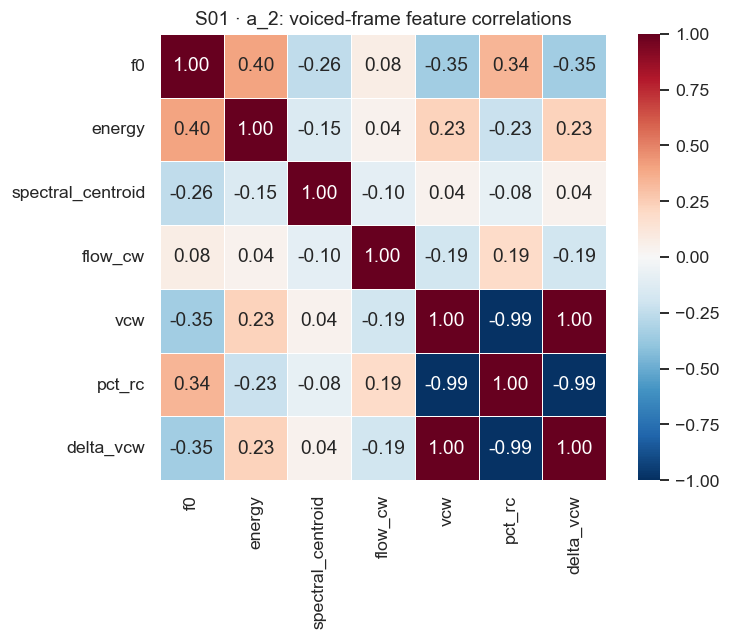

In [7]:

cols = ['f0', 'energy', 'spectral_centroid', 'flow_cw', 'vcw', 'pct_rc', 'delta_vcw']
corr = voiced[cols].corr()
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title(f"{anon(SID)} · {TASK}: voiced-frame feature correlations")
plt.tight_layout(); plt.show()

**Observations:**\
Task `a_2` (maximum phonation time on /a/), one example subject.\
Block structure is visible. `energy` tracks `vcw` and `delta_vcw` (loudness with volume).\
`vcw`, `delta_vcw` and `pct_rc` move together: the kinematics are near-redundant under monotonic depletion.\
`f0` and `flow_cw` sit largely independent of the rest, consistent with §3.\
This is within a single recording. The cohort picture is built in notebook n°3.

## 6. Spectral representations stored in the HDF5
`PairedFeatureExtractor.save_hdf5` also persists the full **STFT power spectrogram**, the **mel-spectrogram**, and the **MFCC** matrix, so the raw `.wav` is not needed to inspect the time-frequency content. We read them directly with `h5py`.

In [8]:

with h5py.File(H5, 'r') as f:
    S_power = f['stft'][:]    # (n_freq, n_frames) power spectrogram
    M_power = f['mel'][:]     # (n_mels, n_frames)
    MFCC    = f['mfcc'][:]    # (13, n_frames)
SR  = int(meta['sr_audio']); HOP = int(meta['hop_length'])
print(f"stft {S_power.shape} | mel {M_power.shape} | mfcc {MFCC.shape}  (sr={SR}, hop={HOP})")

stft (721, 1086) | mel (64, 1086) | mfcc (13, 1527)  (sr=48000, hop=720)


### 6a. STFT spectrogram (log-frequency)

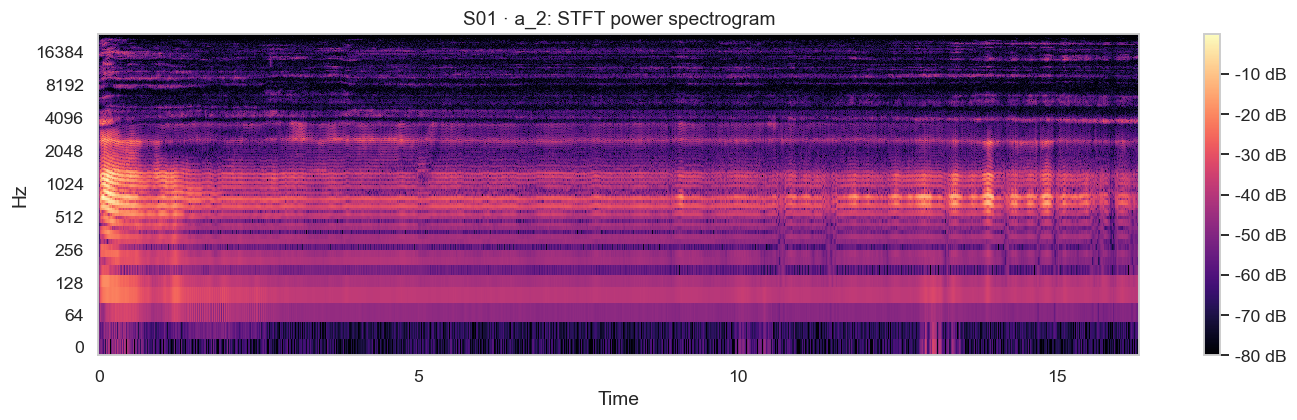

In [9]:

S_db = librosa.power_to_db(S_power, ref=np.max)
fig, ax = plt.subplots(figsize=(13, 4))
img = librosa.display.specshow(S_db, sr=SR, hop_length=HOP, x_axis='time', y_axis='log',
                               ax=ax, cmap='magma')
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set_title(f"{anon(SID)} · {TASK}: STFT power spectrogram")
plt.tight_layout(); plt.show()

**Observations:**\
Task `a_2` (maximum phonation time on /a/), one example subject.\
Horizontal harmonic bands (a periodic vowel) sit at integer multiples of F0, and their slow drift is the F0 contour.\
Energy concentrates low, in the formants.\
The broadband vertical streak at onset is the attack that the `energy` feature over-weights.

### 6b. Mel-spectrogram

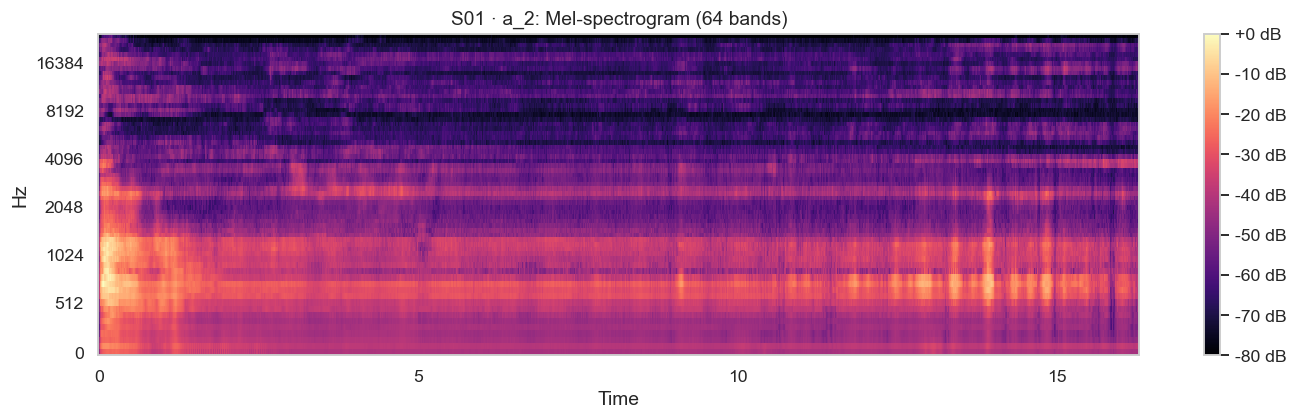

In [10]:

M_db = librosa.power_to_db(M_power, ref=np.max)
fig, ax = plt.subplots(figsize=(13, 4))
img = librosa.display.specshow(M_db, sr=SR, hop_length=HOP, x_axis='time', y_axis='mel',
                               ax=ax, cmap='magma')
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set_title(f"{anon(SID)} · {TASK}: Mel-spectrogram (64 bands)")
plt.tight_layout(); plt.show()

**Observations:**\
Task `a_2` (maximum phonation time on /a/), one example subject.\
The mel scale compresses the highs, so harmonic detail collapses into the formant envelope.\
That perceptually-weighted spectral shape is what the MFCCs summarise.

### 6c. MFCC heatmap
13 mel-frequency cepstral coefficients over time (z-normalised per coefficient).

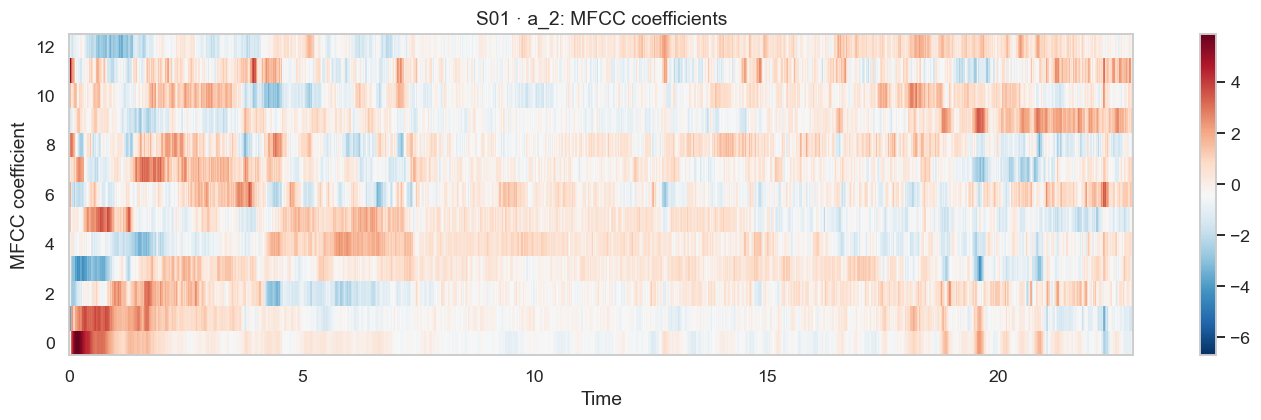

In [11]:

fig, ax = plt.subplots(figsize=(13, 4))
img = librosa.display.specshow(MFCC, sr=SR, hop_length=HOP, x_axis='time', ax=ax, cmap='RdBu_r')
fig.colorbar(img, ax=ax)
ax.set_ylabel('MFCC coefficient'); ax.set_yticks(range(0, 13, 2))
ax.set_title(f"{anon(SID)} · {TASK}: MFCC coefficients")
plt.tight_layout(); plt.show()

**Observations:**\
Task `a_2` (maximum phonation time on /a/), one example subject.\
MFCC-0 (log-energy) dominates the range.\
Higher coefficients (spectral shape) are far more stable across the sustained vowel: a steady articulatory posture.\
These feed the Milestone 2 (M2) MFCC and respiratory analysis in notebook n°3.

## 7. Reusing the package `Visualizer`
The two plots below come straight from `pneumophonic_analysis.visualization.Visualizer`, the class used across the legacy pipeline. First the **F0 trace** with its mean ± 1 SD band.

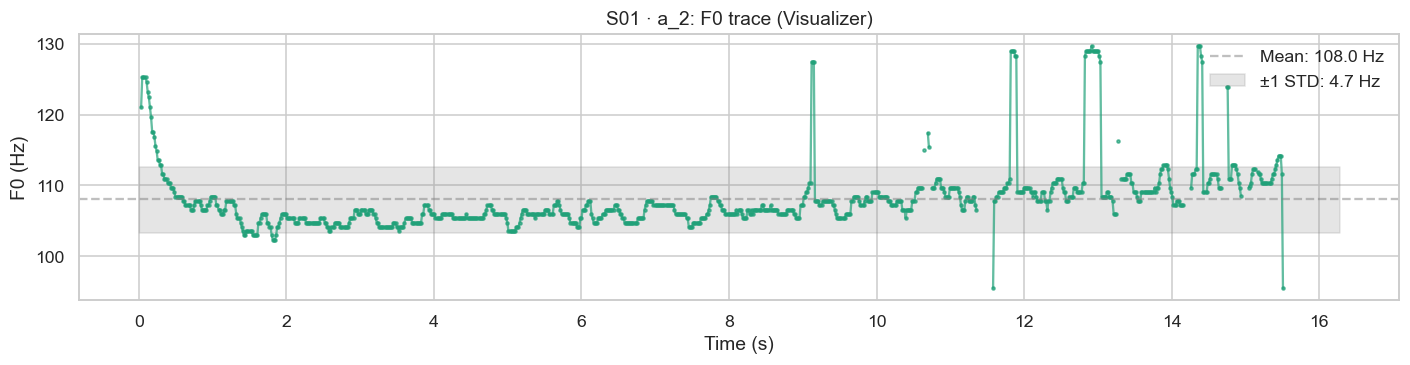

In [12]:

viz = Visualizer()
f0_frame_rate = 1.0 / (df['time'].iloc[1] - df['time'].iloc[0])   # ~66.7 fps
hop_equiv = int(round(SR / f0_frame_rate))
fig = viz.plot_f0_trace(df['f0'].values, hop_length=hop_equiv, sr=SR,
                        title=f"{anon(SID)} · {TASK}: F0 trace (Visualizer)")
fig.set_size_inches(13, 3.5)
plt.tight_layout(); plt.show()

**Observations:**\
Task `a_2` (maximum phonation time on /a/), one example subject.\
The `Visualizer` F0 trace for this steady /a/ is near-flat, with a small vibrato-like ripple.\
The mean ± 1 SD band is narrow, confirming the held pitch seen in §3.

### 7b. Chest-wall volume with FRC zones
Task `a_2` (maximum phonation time on /a/), one example subject.\
`Visualizer.plot_oep_volume` shades the recording into above-FRC (elastic recoil) and below-FRC (active expiratory effort) regions. The FRC crossing is located with the genuine baseline-derived detector also used by the L3 and FRC analyses in notebook n°4.

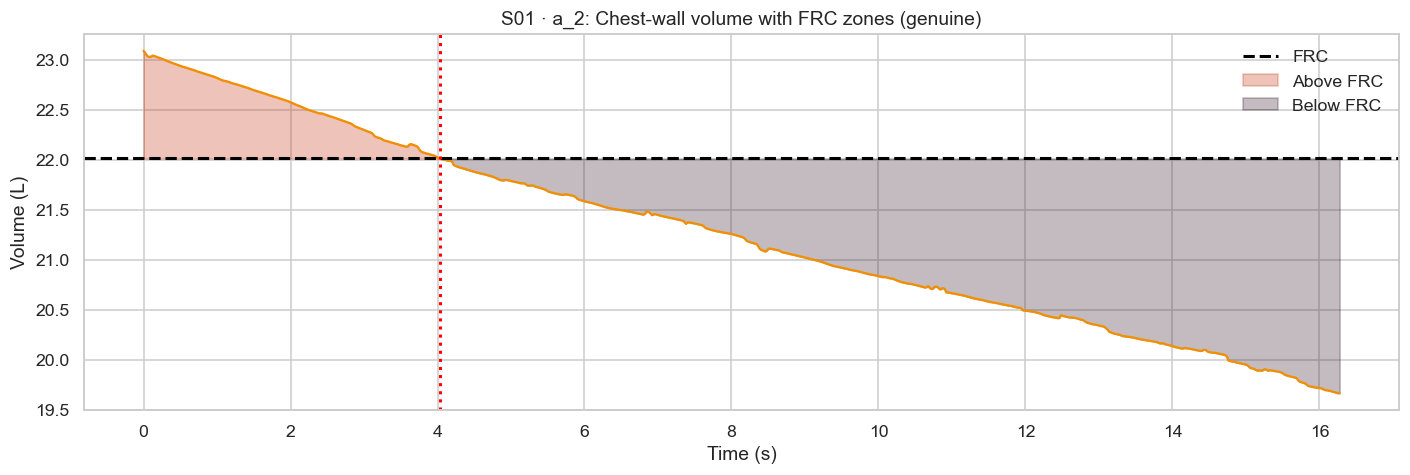

FRC level = 22.014 L (baseline-derived); crossing at frame 269 (t = 4.04s)


In [13]:
from analyze_l3_stratified import find_frc_crossing_index, find_genuine_frc_crossing
vcw = df['vcw'].values
frc_level = float(meta['frc_volume']) if np.isfinite(meta.get('frc_volume', float('nan'))) else float(np.median(vcw))
cross = find_genuine_frc_crossing(df['delta_vcw_frc'].values) if 'delta_vcw_frc' in df.columns else None
if cross is None:   # phonation never crosses true FRC -> onset-referenced fallback
    cross = find_frc_crossing_index(df['delta_vcw'].values)
    frc_level = float(vcw[cross]) if cross is not None else frc_level
fig = viz.plot_oep_volume(vcw, fs_oep=f0_frame_rate, frc_level=frc_level,
                          frc_cross_sample=cross,
                          title=f"{anon(SID)} · {TASK}: Chest-wall volume with FRC zones (genuine)")
fig.set_size_inches(13, 4.5)
plt.tight_layout(); plt.show()
print(f"FRC level = {frc_level:.3f} L (baseline-derived); crossing at frame {cross}"
      + (f" (t = {df['time'].iloc[cross]:.2f}s)" if cross is not None else ""))

**Observations:**\
Task `a_2` (maximum phonation time on /a/), one example subject.\
`Vcw` falls monotonically through the resting FRC level (dashed, baseline-derived).\
Phonation starts above FRC (inspiratory reserve) and continues below it (expiratory reserve).\
This above/below-FRC split is carried into the effect-size analysis in notebook n°4.

## Recap
From a single paired HDF5 file we reproduced every per-recording plot the Milestone 1 visualization scripts produce, plus the stored time-frequency representations, with no raw audio required.\
The next notebook (n°3) aggregates these recordings across the whole cohort for the Milestone 2 (M2) correlation study.